In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pickle


s_list = [5]
Ry_list = [0.6]
no_datasets = 1

In [55]:
result = dict()
for i in range(no_datasets):
    for (s, Ry) in zip(s_list, Ry_list):
        with open(f'out_{i}_{s}_{Ry}.pickle', 'rb') as handle:
            result[i, s, Ry] = pickle.load(handle)

In [3]:
for i in range(no_datasets):
    for (s, Ry) in zip(s_list, Ry_list):
        q_vs, R2_vs, z_vs, beta_vs, sigma2_vs = result[i, s, Ry]

        plt.hist(R2_vs)
        plt.title(f"R2_hist_{i}_{s}_{Ry}.png")
        plt.savefig(f'R2_hist_{i}_{s}_{Ry}.png')
        plt.close()

        plt.hist(q_vs)
        plt.title(f"q_hist_{i}_{s}_{Ry}.png")
        plt.savefig(f'q_hist_{i}_{s}_{Ry}.png')
        plt.close()


        plt.hist(sigma2_vs)
        plt.title(f"sigma2_hist_{i}_{s}_{Ry}.png")
        plt.savefig(f'sigma2_hist_{i}_{s}_{Ry}.png')
        plt.close()

In [39]:
import jax.numpy as jnp
import jax
z = [0, 1, 0]
X = [[2, 3, 4], [5, 6, 7], [8, 9, 10]]
X = jnp.array(X)
z = jnp.array(z)
print(reconstruct(X, z))

[[3. 0. 0.]
 [6. 0. 0.]
 [9. 0. 0.]]


In [41]:
reconstruct(X, z).T@reconstruct(X, z)

Array([[126.,   0.,   0.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.]], dtype=float32)

In [81]:
jnp.where(z == 1, X, z)

Array([[0, 3, 0],
       [0, 6, 0],
       [0, 9, 0]], dtype=int32)

In [82]:
z

Array([0, 1, 0], dtype=int32)

In [60]:
import numpy as np

grid = [i for i in jnp.arange(0.001, 0.101, 0.001)]
grid += [i for i in jnp.arange(0.11, 0.91, 0.01)]
grid += [i for i in jnp.arange(0.901, 1, 0.001)]

In [61]:

grid = np.array(grid)
surface = np.zeros(len(grid))

In [62]:

surface[:-1] = np.sum(
    np.array([[(grid[i] - grid[i - 1]) * (grid[j] - grid[j - 1]) for i in range(1, len(grid))] for j in
               range(1, len(grid))]), axis=1)
surface[-1] = surface[-2]

In [63]:
len(grid)

279

In [32]:
result

{(0,
  5,
  0.9): (Array([0.058     , 0.14999999, 0.10000001, 0.07800001, 0.072     ,
         0.047     , 0.053     , 0.028     , 0.045     , 0.06      ,
         0.042     , 0.056     , 0.028     , 0.053     , 0.09100001,
         0.10000001, 0.086     , 0.07400001, 0.06      , 0.08000001,
         0.04      , 0.055     , 0.034     , 0.034     , 0.042     ,
         0.056     , 0.063     , 0.039     , 0.034     , 0.02      ,
         0.037     , 0.035     , 0.082     , 0.028     , 0.058     ,
         0.057     , 0.07600001, 0.054     , 0.068     , 0.053     ,
         0.063     , 0.033     , 0.053     , 0.038     , 0.044     ,
         0.03      , 0.051     , 0.07300001, 0.06500001, 0.079     ,
         0.10000001, 0.068     , 0.09      , 0.02      , 0.044     ,
         0.026     , 0.038     , 0.05      , 0.042     , 0.08800001,
         0.05      , 0.027     , 0.033     , 0.10000001, 0.068     ,
         0.082     , 0.038     , 0.07000001, 0.026     , 0.027     ,
         0.071   

In [4]:
result

{(0,
  5,
  0.25): (Array([0.39999992, 0.27999997, 0.32999995, 0.23999996, 0.40999997,
         0.094     , 0.21999997, 0.13      , 0.21999997, 0.11      ,
         0.26999998, 0.11      , 0.13      , 0.10000001, 0.11      ,
         0.28999996, 0.28999996, 0.37999994, 0.36999995, 0.39999992,
         0.29999995, 0.30999994, 0.13      , 0.22999997, 0.11      ,
         0.29999995, 0.13      , 0.48999995, 0.11      , 0.30999994,
         0.009     , 0.08100001, 0.083     , 0.16999999, 0.059     ,
         0.4699999 , 0.10000001, 0.35999995, 0.13      , 0.69999987,
         0.083     , 0.4699999 , 0.034     , 0.22999997, 0.023     ,
         0.21999997, 0.062     , 0.26999998, 0.16      , 0.23999996,
         0.19999999, 0.20999998, 0.22999997, 0.20999998, 0.10000001,
         0.6499999 , 0.043     , 0.5499999 , 0.024     , 0.19999999,
         0.10000001, 0.09600001, 0.16999999, 0.17999998, 0.22999997,
         0.16999999, 0.13      , 0.18999998, 0.10000001, 0.10000001,
         0.13999

(array([ 5., 12., 18., 13., 20., 16.,  7.,  3.,  3.,  3.]),
 array([1.73250604, 1.86191738, 1.99132872, 2.12074018, 2.2501514 ,
        2.37956285, 2.50897431, 2.63838553, 2.76779699, 2.89720821,
        3.02661967]),
 <BarContainer object of 10 artists>)

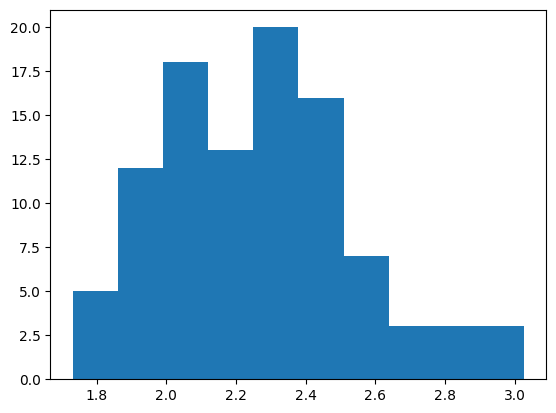

In [61]:
plt.hist(result[i, s, Ry][4], bins=10)

In [45]:
result

{(0,
  5,
  0.5): (Array([0.44999993, 0.6799999 , 0.6799999 , 0.6099999 , 0.5499999 ,
         0.4699999 , 0.4699999 , 0.5199999 , 0.49999994, 0.45999992,
         0.37999994, 0.36999995, 0.36999995, 0.35999995, 0.33999997,
         0.30999994, 0.39999992, 0.38999993, 0.41999996, 0.50999993,
         0.5399999 , 0.5899999 , 0.5399999 , 0.4799999 , 0.4699999 ,
         0.5199999 , 0.49999994, 0.48999995, 0.49999994, 0.44999993,
         0.40999997, 0.30999994, 0.39999992, 0.41999996, 0.40999997,
         0.42999995, 0.45999992, 0.49999994, 0.5299999 , 0.5999999 ,
         0.4799999 , 0.48999995, 0.5199999 , 0.49999994, 0.40999997,
         0.36999995, 0.39999992, 0.40999997, 0.35999995, 0.36999995,
         0.31999993, 0.33999997, 0.33999997, 0.37999994, 0.41999996,
         0.5399999 , 0.50999993, 0.50999993, 0.4699999 , 0.43999994,
         0.49999994, 0.44999993, 0.4699999 , 0.49999994, 0.43999994,
         0.48999995, 0.44999993, 0.42999995, 0.39999992, 0.42999995,
         0.519999